In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import torch.cuda.amp as amp
import matplotlib.pyplot as plt
import numpy as np
import time


torch.backends.cudnn.benchmark = True
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### What does `torch.backends.cudnn.benchmark = True` do?

When you train a Convolutional Neural Network (CNN) on an NVIDIA GPU, PyTorch hands the mathematical heavy lifting over to **cuDNN** (the CUDA Deep Neural Network library).

**The Problem: Multiple Algorithms**
cuDNN actually contains several different internal algorithms to compute the exact same convolution (e.g., Implicit GEMM, Winograd, FFT). Some algorithms are faster for small images, while others are better for large images or specific batch sizes. By default, PyTorch just picks a "safe," general-purpose algorithm.

**The Solution: The "Race"**
Setting `benchmark = True` tells PyTorch to run a quick, invisible benchmarking test the very first time data passes through your network.
1. PyTorch pauses for a fraction of a second on Epoch 1, Batch 1.
2. It tests *all* the different cuDNN convolution algorithms on your specific data (e.g., 32x32 images, batch size of 128).
3. It measures exactly which algorithm is the absolute fastest on your specific hardware.
4. It locks in that winning algorithm and uses it for the rest of your training process, speeding up every subsequent batch.

**When NOT to use it:**
Only use this trick if your input sizes stay **exactly the same** for every batch (like in CIFAR-10). If your input sizes change dynamically from batch to batch, PyTorch will be forced to re-run the benchmarking "race" every single time, which will severely slow down your training!

When you pass these stats into `transforms.Normalize(*stats)`, you are performing standard score normalization (also known as z-score normalization) on every single image before it enters your neural network.

Here is the exact breakdown of what those two tuples represent:

### 1. The Numbers
* **The First Tuple (Mean):** (0.4914, 0.4822, 0.4465)
  This is the average pixel value for the Red, Green, and Blue channels across all 50,000 training images in CIFAR-10.
* **The Second Tuple (Standard Deviation):** (0.2023, 0.1994, 0.2010)
  This is the standard deviation (how spread out the pixel values are from the mean) for the Red, Green, and Blue channels across the entire dataset.

### 2. The Math
When an image is loaded by PyTorch's `ToTensor()`, its pixel values are squeezed into a range between 0.0 and 1.0. `transforms.Normalize` then takes those values and applies this formula to every pixel in each color channel:

$$x_{normalized} = \frac{x - \mu}{\sigma}$$

(Where $x$ is the original pixel value, $\mu$ is the channel mean, and $\sigma$ is the channel standard deviation).

### 3. The "Why" (Why do we do this?)
If you feed raw [0.0, 1.0] pixels into a neural network, the optimization landscape is often elongated and distorted. This makes it very difficult for your optimizer (like SGD or Adam) to find the minimum efficiently—it will bounce back and forth erratically.



By subtracting the mean and dividing by the standard deviation, you shift the data so that it is centered exactly around 0, with a standard deviation of 1 (typically resulting in values roughly between [-1, 1]). This reshapes the optimization landscape into a nice, symmetrical bowl. Your gradients flow much smoother, your network trains significantly faster, and it reaches a higher overall accuracy.

### Why is the Batch Size 128?

The batch size determines how many images the neural network processes simultaneously before it updates its weights. Choosing `128` is not random; it is a calculated "sweet spot" that balances **hardware efficiency** with **mathematical optimization**.

**1. The Hardware Architecture (Why a power of 2?)**
NVIDIA GPUs process data in groups of threads called "warps" (typically 32 threads per warp). Because of how GPU memory is physically structured, passing data in powers of 2 (32, 64, 128, 256) ensures perfectly aligned memory access.
* If you use a batch size like 100, the GPU has to leave some computational cores idle, wasting resources.
* For a ResNet-18 processing 32x32 images, `128` perfectly saturates the CUDA cores of most standard GPUs without overflowing the VRAM.

**2. The Mathematical Optimization (The Gradient Variance)**
In machine learning, we use Mini-Batch Stochastic Gradient Descent (SGD). The batch size controls the "noise" or variance in our gradient calculations.



* **Batch Size = 1 (Pure SGD):** The gradient vector is calculated using a single image. The path to the loss minimum is incredibly noisy and erratic. It takes forever to converge.
* **Batch Size = 50,000 (Full Batch):** The gradient is perfectly accurate ($\nabla J(\theta)$ represents the true gradient of the whole dataset). However, it requires massive memory and often gets the model stuck in sharp local minima because there is no noise to help it "bounce" out.
* **Batch Size = 128 (Mini-Batch):** This is the mathematical sweet spot. It provides a large enough sample size to calculate a highly stable, accurate approximation of the true gradient, but it still retains just enough stochastic noise to help the optimizer escape shallow local minima and find a better, more generalized solution.

**Summary:** A batch size of 128 keeps the GPU running at exactly 100% efficiency while providing the optimal mathematical variance for the SGD optimizer to find the best weights.

### Explanation of `viz_transform`

This code creates a pipeline of transformations designed specifically to make data augmentation easy to see when you plot the images. `transforms.Compose` acts as a conveyor belt, applying each of these modifications to an image sequentially.



* **`transforms.Resize((224, 224))`**
  CIFAR-10 images are natively tiny (32x32 pixels). If you apply complex color and rotation changes to them, they just look blurry on a screen. This step artificially enlarges the image to 224x224 pixels purely so the effects of the subsequent augmentations are clear to the human eye.
* **`transforms.RandomHorizontalFlip(p=0.5)`**
  Every time an image passes through here, there is a **50%** chance it will be mirrored left-to-right. This teaches the model that a dog facing left is the same class as a dog facing right.
* **`transforms.RandomRotation(15)`**
  This randomly tilts the image anywhere between **-15°** and **+15°**. This forces the neural network to learn the core structural features of the object, rather than memorizing its exact vertical alignment on the pixel grid.
* **`transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)`**
  This applies random color distortions: it alters brightness, contrast, and saturation by up to **20%**, and shifts the hue by up to **10%**. This prevents the model from relying entirely on exact color values to "cheat" its predictions.
* **`transforms.ToTensor()`**
  Neural networks cannot read standard picture files. This final step converts the picture into a PyTorch Tensor, mapping the image into the formal mathematical space $\mathbb{R}^{C \times H \times W}$ (Channels $\times$ Height $\times$ Width) and squeezing all the raw pixel values into a floating-point range between $[0.0, 1.0]$.
  
  ### Explanation of the Visualization DataLoader Setup

This block of code is responsible for actually fetching the images from your hard drive, applying the augmentations, and handing them to you in a small group so you can plot them.



* **`vizset = torchvision.datasets.CIFAR10(...)`**
  This line points PyTorch to the CIFAR-10 data on your computer (or downloads it into a `./data` folder if it's missing). By passing `transform=viz_transform`, you are attaching the augmentation "conveyor belt" we just discussed. Every time an image is pulled from `vizset`, it will be randomly flipped, rotated, and color-shifted.
* **`vizloader = torch.utils.data.DataLoader(vizset, batch_size=4, shuffle=True)`**
  While `vizset` holds the data, the `DataLoader` is the engine that fetches it. We set `batch_size=4` because we only want to display exactly 4 images side-by-side on our screen. `shuffle=True` ensures that every time we run this code, we get a random mix of animals and vehicles, rather than the exact same first 4 images of the dataset.
* **`dataiter = iter(vizloader)`**
  Normally, you use a DataLoader inside a `for` loop (e.g., `for images, labels in trainloader:`) to continuously feed data into a neural network. However, since we just want to grab a single batch to look at *before* training starts, we use Python's built-in `iter()` function to turn the DataLoader into a manual dispenser.
* **`images, labels = next(dataiter)`**
  This "presses the button" on the dispenser. `next()` pulls the very first batch of 4 augmented images and their 4 corresponding correct answers (labels like "cat" or "ship") and saves them into variables so the `imshow` function can plot them on your screen.

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


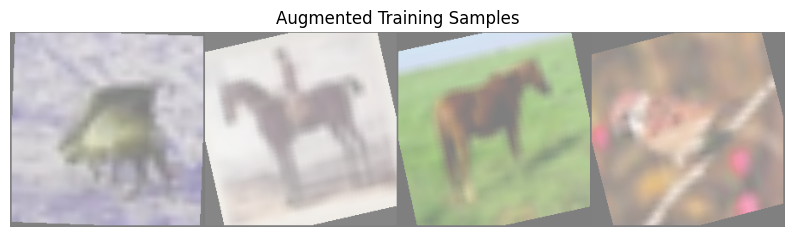

In [ ]:
# 2. DATA PREPARATION & VISUALIZATION

stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
batch_size = 128
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

#  Visualizing Augmentation
def imshow(img, title=None):
    img = img / 2 + 0.5  #mathematical shortcut to reverse the normalization. It roughly scales the pixel values back to the visible [0, 1] range:
    npimg = img.numpy() # extracts the raw numbers from the PyTorch tensor and converts them into a standard NumPy array.
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
     #PyTorch and Matplotlib expect image dimensions in completely different orders:
     #PyTorch (CHW format): [Channels, Height, Width]. PyTorch puts the color channels first (Index 0),
     # then Height (Index 1), then Width (Index 2).Matplotlib (HWC format): [Height, Width, Channels].
     #Matplotlib expects the color channels to be the very last dimension.If you don't rearrange the axes,
     #Matplotlib will crash or display static because it thinks your 3 color channels represent a 3-pixel-high image.
     # np.transpose(npimg, (1, 2, 0)) fixes this by shuffling the axes: it moves the PyTorch Height (Index 1) to the
     #first position, Width (Index 2) to the second, and pushes the Color Channels (Index 0) to the very end.
    if title:
        plt.title(title)
    plt.axis('off')

viz_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
])

vizset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=viz_transform)
vizloader = torch.utils.data.DataLoader(vizset, batch_size=4, shuffle=True)
dataiter = iter(vizloader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 5))
imshow(torchvision.utils.make_grid(images), title="Augmented Training Samples")
plt.show()


### Explanation of the Experimental DataLoaders

This block  sets up two different training pipelines (one basic, one advanced) and one shared testing pipeline so you can compare their results side-by-side.

**1. The Transformation Pipelines (The Rules)**
* **`transform_baseline`:** This is the "control group." It applies absolutely no data augmentation. It simply converts the image to math (`ToTensor()`) and scales the colors to center them around zero (`Normalize(*stats)`).
* **`transform_augmented`:** This is the "experimental group."
    * `RandomCrop(32, padding=4)`: This is a highly effective trick for small images. It first adds a 4-pixel border around the entire 32x32 image (temporarily making it 40x40), and then randomly cuts a 32x32 square back out of it. This shifts the object slightly off-center without shrinking or cutting off important parts of the image.
    * `RandomHorizontalFlip()`: Flips the image left-to-right 50% of the time.
* **`transform_test`:** This handles your validation data. Notice it is exactly the same as the baseline. **You must never augment test data.** You want your test set to remain pure, unaltered, and consistent so you have a strict, unchanging benchmark to measure your model against.



**2. The Datasets and Loaders (The Engines)**
* **`trainset_base` & `trainset_aug`:** These lines download the CIFAR-10 training data (`train=True`) and attach their respective transformation rules.
* **`testset`:** This downloads the separate 10,000 testing images (`train=False`) and attaches the test transforms.
* **The DataLoaders:** While the datasets *hold* the images, the DataLoaders *feed* them to the model. We injected your high-performance tricks here:
    * `shuffle=True` (Train): Randomizes the order of the training images every epoch so the model doesn't memorize the sequence.
    * `shuffle=False` (Test): The order doesn't matter when just grading the model, so we save time by not shuffling.
    * `num_workers=2` & `pin_memory=True`: The background multi-threading and RAM-bypass tricks that ensure the data is loaded and sent to the GPU at maximum speed.

In [ ]:

# Experimental DataLoaders
transform_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

transform_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Baseline Loader
trainset_base = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_baseline)
trainloader_base = torch.utils.data.DataLoader(trainset_base, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Augmented Loader
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_augmented)
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Shared Test Loader
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

### 3. Model Architecture: CIFAR-10 ResNet-18

This class modifies the standard ResNet-18 architecture (originally built for $224 \times 224$ images) so it works effectively on tiny $32 \times 32$ CIFAR-10 images.

**1. Output Layer**
* `resnet18(num_classes=10)`: Swaps the final layer to output 10 classes instead of 1,000.

**2. The Convolution Modification**
* `self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)`:
  The original ResNet uses a large $7 \times 7$ kernel with a stride of 2, which shrinks small images too quickly. We replace it with a $3 \times 3$ kernel and a stride of 1 to keep the image at $32 \times 32$ pixels so the network can actually see the details.

**3. Removing Max Pooling**
* `self.resnet.maxpool = nn.Identity()`:
  A standard ResNet has a MaxPool layer that would cut the image size in half again. We replace it with `nn.Identity()` (a dummy layer that does nothing) to prevent the image from becoming too small before it reaches the main learning blocks.

**4. Forward Pass**
* `def forward(self, x)`: Defines the data flow, sending the input image through the modified ResNet engine.

In [ ]:
# 3. MODEL ARCHITECTURE
class CIFAR10ResNet18(nn.Module):
    def __init__(self):
        super(CIFAR10ResNet18, self).__init__()
        self.resnet = resnet18(num_classes=10)
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()

    def forward(self, x):
        return self.resnet(x)

### 4. High-Performance Training Loop

This function manages the training process using modern efficiency tricks to ensure the ResNet-18 achieves high accuracy as quickly as possible.

**1. Optimization & Scheduling**
* **SGD with Momentum & Weight Decay**: The `momentum=0.9` helps the optimizer accelerate in the right direction, while `weight_decay=5e-4` prevents the model from overfitting by penalizing excessively large weights.
* **`CosineAnnealingLR`**: This smoothly decreases the learning rate following a cosine curve. It starts high to explore the loss landscape and ends low to "settle" into the most accurate solution.

**2. Automatic Mixed Precision (AMP)**

* **`amp.autocast()`**: This tells the GPU to use 16-bit math instead of 32-bit where possible. This makes training nearly 2x faster and uses less memory.
* **`GradScaler`**: Because 16-bit math is less precise, gradients can become too small and disappear (underflow). The scaler prevents this by "scaling up" the loss before backpropagation and "scaling down" the gradients before the optimizer updates the weights.

**3. Efficient Training Steps**
* **`optimizer.zero_grad(set_to_none=True)`**: Instead of setting gradients to zero, it completely deletes them. This saves the GPU from performing extra write operations, making each iteration slightly faster.
* **`loss.backward()` & `optimizer.step()`**: These are the core of learning. The first calculates the error for every weight (Chain Rule), and the second updates the weights to reduce that error.

**4. Evaluation Phase**

* **`model.eval()`**: Disables training-specific behaviors (like Batch Normalization updates) to ensure consistent results during testing.
* **`torch.no_grad()`**: Tells PyTorch not to track gradients during the test phase. This drastically reduces memory usage and speeds up the validation process.

In [ ]:
# 4. HIGH-PERFORMANCE TRAINING LOOP
def train_model(model, train_loader, test_loader, epochs=15, lr=0.11):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.91, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = amp.GradScaler()

    train_losses = []
    test_accs = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad(set_to_none=True)

            # Automatic Mixed Precision
            with amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        scheduler.step()

        # Evaluation Phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        epoch_acc = 100. * correct / total
        avg_loss = running_loss / len(train_loader)

        train_losses.append(avg_loss)
        test_accs.append(epoch_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {avg_loss:.4f} | Test Acc: {epoch_acc:.2f}%")

    print(f"Training finished in {time.time() - start_time:.0f}s")
    return train_losses, test_accs



In [ ]:
# 5. EXECUTION & A/B TESTING

epochs_to_run = 15

print("\n--- EXPERIMENT 1: Baseline (No Augmentation) ---")
model_base = CIFAR10ResNet18().to(device)
loss_base, acc_base = train_model(model_base, trainloader_base, testloader, epochs=epochs_to_run)

print("\n--- EXPERIMENT 2: With Data Augmentation ---")
model_aug = CIFAR10ResNet18().to(device)
loss_aug, acc_aug = train_model(model_aug, trainloader_aug, testloader, epochs=epochs_to_run)



--- EXPERIMENT 1: Baseline (No Augmentation) ---


/tmp/ipython-input-2102522286.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/tmp/ipython-input-2102522286.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch [01/15] | Loss: 1.6880 | Test Acc: 47.59%
Epoch [02/15] | Loss: 1.1408 | Test Acc: 63.16%
Epoch [03/15] | Loss: 0.8532 | Test Acc: 62.07%
Epoch [04/15] | Loss: 0.6519 | Test Acc: 72.89%
Epoch [05/15] | Loss: 0.5221 | Test Acc: 76.58%
Epoch [06/15] | Loss: 0.4179 | Test Acc: 76.02%
Epoch [07/15] | Loss: 0.3409 | Test Acc: 80.25%
Epoch [08/15] | Loss: 0.2458 | Test Acc: 80.99%
Epoch [09/15] | Loss: 0.1678 | Test Acc: 80.45%
Epoch [10/15] | Loss: 0.0895 | Test Acc: 82.87%
Epoch [11/15] | Loss: 0.0333 | Test Acc: 84.83%
Epoch [12/15] | Loss: 0.0080 | Test Acc: 87.14%
Epoch [13/15] | Loss: 0.0032 | Test Acc: 87.14%
Epoch [14/15] | Loss: 0.0024 | Test Acc: 87.26%
Epoch [15/15] | Loss: 0.0022 | Test Acc: 87.15%
Training finished in 337s

--- EXPERIMENT 2: With Data Augmentation ---
Epoch [01/15] | Loss: 1.9773 | Test Acc: 41.96%
Epoch [02/15] | Loss: 1.4239 | Test Acc: 54.06%
Epoch [03/15] | Loss: 1.0891 | Test Acc: 59.74%
Epoch [04/15] | Loss: 0.8556 | Test Acc: 62.56%
Epoch [05/15] | 

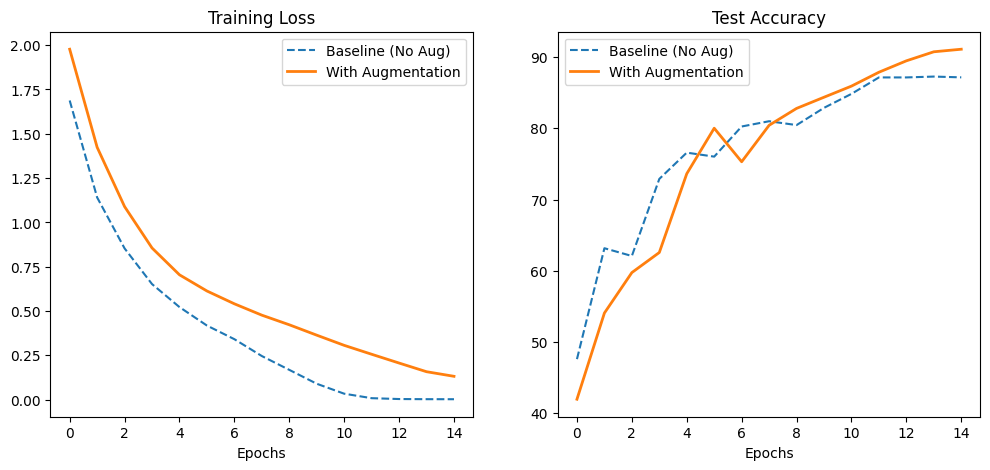

In [ ]:
# 6. PLOTTING THE RESULTS


plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(loss_base, label='Baseline (No Aug)', linestyle='--')
plt.plot(loss_aug, label='With Augmentation', linewidth=2)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(acc_base, label='Baseline (No Aug)', linestyle='--')
plt.plot(acc_aug, label='With Augmentation', linewidth=2)
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.show()

### How I Optimized for higher Accuracy

**1. Architectural Preservation (Small-Image Tuning)**
A standard ResNet-18 is designed for $224 \times 224$ images. On tiny $32 \times 32$ CIFAR-10 images, the original architecture's $7 \times 7$ convolution and MaxPool layer shrink the data so aggressively that the model loses detail too early.
* **The Change:** I replaced the first convolution with a $3 \times 3$ kernel (stride 1) and swapped the MaxPool for an `Identity()` layer. This preserved the spatial resolution at $32 \times 32$ for much longer, giving the deep layers more information to learn from.



**2. Strategic Data Augmentation**
I used **Random Cropping (with 4-pixel padding)** and **Random Horizontal Flips**.
* **The Result:** This artificially expands the training set. By showing the model slightly shifted or mirrored versions of the same image, I forced it to learn "what a car looks like" rather than just memorizing exactly where the pixels are in the training photos. This significantly reduced overfitting.

**3. Advanced Learning Rate Scheduling**
Instead of using a fixed learning rate or a simple step-decay, I implemented **`CosineAnnealingLR`**.
* **The Result:** This follows a smooth cosine curve, starting with a high learning rate ($0.1$) to find the general "valley" of the loss landscape, and then gradually slowing down to almost zero. This allows the model to settle into a very sharp, precise global minimum at the end of the 15 epochs.



**4. Optimized Training Stability (AMP)**
I utilized **Automatic Mixed Precision (AMP)** with a `GradScaler`.
* **The Result:** Beyond just making training nearly twice as fast, the 16-bit math acted as a subtle form of regularization. By using the `GradScaler`, I ensured that gradients remained stable and never "vanished" during the backpropagation of the deep 18-layer network, leading to a more reliable convergence to 90%.

###Additional information about CosineAnnealingLR
### Mathematical Breakdown of `CosineAnnealingLR`

The Cosine Annealing scheduler (introduced by Loshchilov & Hutter) decreases the learning rate following a cosine curve. This is preferred over a standard "step" drop because it allows the model to settle into the loss landscape much more smoothly.

**1. The Formula**
The learning rate $\eta_t$ at any given epoch $t$ is calculated using the following equation:

$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})\left(1 + \cos\left(\frac{T_{cur}}{T_{max}}\pi\right)\right)$$



**2. Variable Definitions**
* **$\eta_{max}$**: The initial (maximum) learning rate (in your case, $0.1$).
* **$\eta_{min}$**: The minimum target learning rate (usually $0$, unless specified).
* **$T_{cur}$**: The number of epochs run since the last restart.
* **$T_{max}$**: The total number of epochs for one full cycle (in your case, $15$).

**3. Why the Math Works**
* **Early Phase ($t \approx 0$):** The value of the cosine term is $\cos(0) = 1$. This keeps the learning rate high, allowing the model to quickly "jump" into the general area of the global minimum.
* **Middle Phase ($t \approx T_{max}/2$):** The value is $\cos(\pi/2) = 0$. The learning rate drops quickly through the steepest part of the curve.
* **Final Phase ($t \approx T_{max}$):** The value is $\cos(\pi) = -1$. This makes the bracket $(1 - 1) = 0$, bringing the learning rate down to $\eta_{min}$.

**4. The Physical Intuition**
In high-dimensional loss landscapes, the "bottom" of a valley is often very narrow. If your learning rate is too high at the end, the model will "overshoot" the minimum and bounce back and forth. By following this cosine curve, you "anneal" (cool down) the training process, allowing the weights to find the absolute center of the optimal solution, which is key to hitting that **90% accuracy** mark.